# Esercizio: Dataset sintetico "DataMarket"

300 ordini e-commerce generati con NumPy (categoria, regione, prezzo, quantità, sconto, età cliente, giorni di consegna, rating, totale), con outlier. 

## Obiettivi dell'esercizio:

* **Relazioni tra variabili numeriche:** scegliere autonomamente sia il grafico sia quali variabili numeriche includere.
* **Confronto tra categorie:** scegliere variabile categorica + variabile numerica da confrontare, poi individuare da soli il grafico più adatto.
* **Proporzioni e gerarchie:** aggregare i dati e scegliere il grafico per rappresentare le proporzioni di fatturato.

---

> **Commento metodologico:**
> * `np.random.gamma()` simula prezzi realistici (distribuzione asimmetrica a destra, com'è tipico dei prezzi reali);
> * `np.random.poisson()` simula tempi di consegna.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

np.random.seed(42)  # Riproducibilità: tutti otterrete gli stessi dati
n = 300

categorie = ['Elettronica', 'Abbigliamento', 'Casa', 'Sport']
regioni = ['Nord', 'Centro', 'Sud', 'Isole']

df = pd.DataFrame({
    'ordine_id': range(1, n + 1),
    'categoria': np.random.choice(categorie, n, p=[0.35, 0.25, 0.25, 0.15]),
    'regione': np.random.choice(regioni, n),
    'prezzo': np.round(np.random.gamma(shape=2, scale=40, size=n), 2),
    'quantita': np.random.randint(1, 6, n),
    'sconto_pct': np.random.choice([0, 5, 10, 15, 20], n, p=[0.4, 0.25, 0.2, 0.1, 0.05]),
    'eta_cliente': np.random.randint(18, 75, n),
    'giorni_consegna': np.random.poisson(lam=4, size=n) + 1,
    'rating': np.clip(np.random.normal(4.2, 0.8, n), 1, 5).round(1)
})

# Calcoliamo il totale ordine (prezzo * quantità * sconto)
df['totale'] = (df['prezzo'] * df['quantita'] * (1 - df['sconto_pct'] / 100)).round(2)

# Iniettiamo qualche outlier realistico in giorni_consegna
outlier_idx = np.random.choice(df.index, 8, replace=False)
df.loc[outlier_idx, 'giorni_consegna'] += np.random.randint(10, 20, 8)

print(df.head())
print(df.info())

   ordine_id      categoria regione  prezzo  quantita  sconto_pct  \
0          1  Abbigliamento    Nord   84.05         3           0   
1          2          Sport   Isole  175.56         4           5   
2          3           Casa   Isole   65.69         1           5   
3          4  Abbigliamento  Centro   27.14         3           0   
4          5    Elettronica     Sud   84.76         3           0   

   eta_cliente  giorni_consegna  rating  totale  
0           71               22     5.0  252.15  
1           50                6     2.8  667.13  
2           53                5     4.0   62.41  
3           48                6     4.9   81.42  
4           31                2     4.0  254.28  
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ordine_id        300 non-null    int64  
 1   categoria        300 non-null    str    
 2   re

## Creazione del Grafico Istogramma

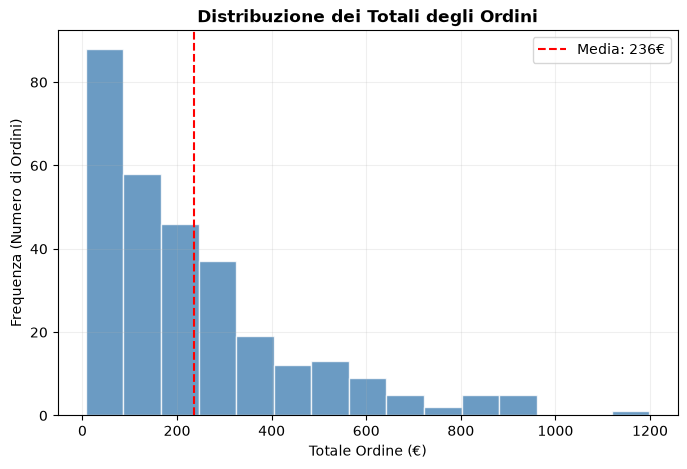

In [6]:
plt.figure(figsize=(8, 5))

# Creazione dell'istogramma
plt.hist(df['totale'], bins=15, edgecolor="white", color="steelblue", alpha=0.8)

# Calcolo e aggiunta della linea della media
media_totale = df['totale'].mean()
plt.axvline(media_totale, color="red", linestyle="--", linewidth=1.5, label=f"Media: {media_totale:.0f}€")

# Personalizzazione del grafico
plt.title("Distribuzione dei Totali degli Ordini", fontsize=12, fontweight="bold")
plt.xlabel("Totale Ordine (€)")
plt.ylabel("Frequenza (Numero di Ordini)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Creazione dell Grafico Scatterplot 

### **Spiegazione**:

1. Lo scatter plot guarda due variabili contemporaneamente. Risponde alla domanda: "C'è una relazione o un legame tra queste due metriche?"

2. Dopo aver capito (grazie all'istogramma) come erano fatte l'età e il prezzo/totale prese singolarmente, le hai incrociate nello scatter plot per vedere se i clienti più anziani spendessero di più o di meno rispetto ai giovani.

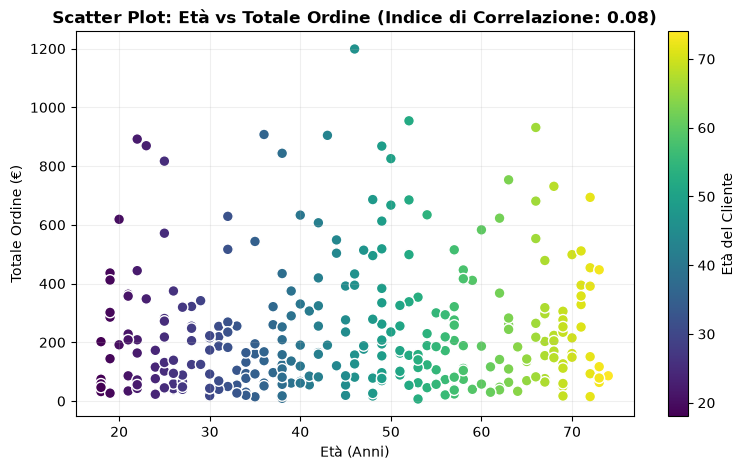

In [5]:
plt.figure(figsize=(9, 5))

# Calcolo del coefficiente di correlazione lineare di Pearson
coeff_corr = df['eta_cliente'].corr(df['totale'])

# Creazione dello scatter plot (il colore dei punti varia in base all'età)
sc = plt.scatter(df['eta_cliente'], df['totale'], c=df['eta_cliente'], s=60, cmap="viridis", edgecolor="white")
plt.colorbar(sc, label="Età del Cliente") # Barra cromatica laterale

plt.title(f"Scatter Plot: Età vs Totale Ordine (Indice di Correlazione: {coeff_corr:.2f})", fontsize=12, fontweight="bold")
plt.xlabel("Età (Anni)")
plt.ylabel("Totale Ordine (€)")
plt.grid(True, alpha=0.2)
plt.show()

## Creazione del bloxplot

1. Permette di confrontare visivamente una variabile categorica con una numerica (es. dividendo i dati in colonne o righe distinte per ogni categoria).

2. È lo strumento statistico d'eccellenza per mostrare gli outlier (i valori anomali). Poiché la traccia dice esplicitamente che nel codice sono stati iniettati degli outlier realistici nella variabile dei tempi di consegna, con il Box Plot li vedrai spuntare chiaramente come dei "pallini" isolati.

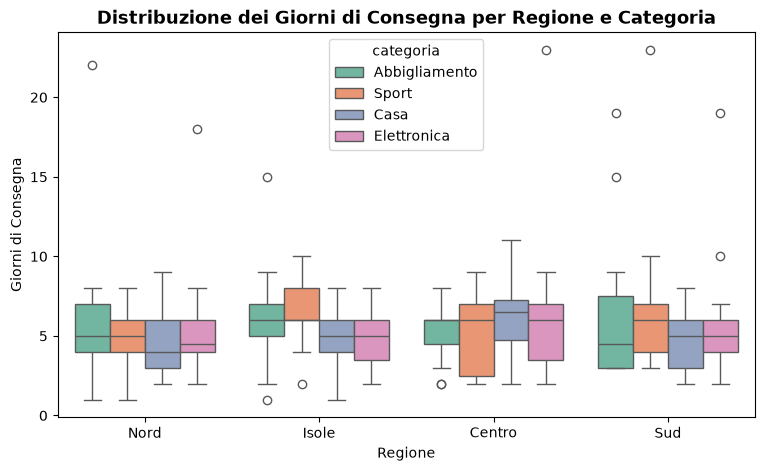

In [7]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="regione", y="giorni_consegna", hue="categoria", palette="Set2")
plt.title("Distribuzione dei Giorni di Consegna per Regione e Categoria", fontsize=13, fontweight="bold")
plt.xlabel("Regione")
plt.ylabel("Giorni di Consegna")
plt.show()